Consider the following input sequence, which has already been embedded into 3-dimension vectors

In [5]:
import torch

In [31]:
inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], #Your
        [0.55, 0.87, 0.66], #Journey
        [0.57, 0.85, 0.64], #starts
        [0.22, 0.58, 0.33], #with
        [0.77, 0.25, 0.10], #one
        [0.05, 0.80, 0.55], #step
    ]
)

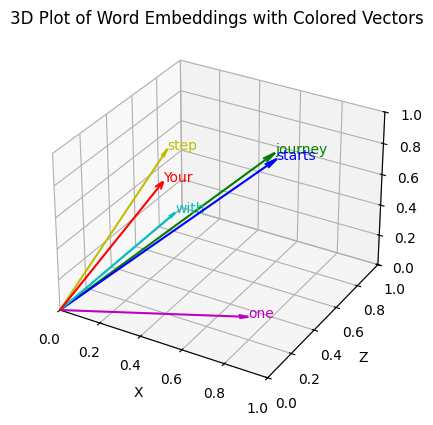

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# extract x,y,z coords
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]
z_coords = inputs[:, 2]

#create 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

for x,y,z,word,color in zip(x_coords, y_coords, z_coords, words, colors):
    #create a vector from origin to the point (x,y,z) 
    ax.quiver(0,0,0,x,y,z, color=color, arrow_length_ratio=0.05)
    ax.text(x,y,z,word,fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel("X")  
ax.set_ylabel("Y")
ax.set_ylabel("Z")

#set plot limits to keep arrows within plot boundaries
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

Lets consider the second word - "journey" as the query

We compute the attention scores by taking the dot product between the query (journey) and every other word in the input vector

We do this to find out how similar or how close the query is to every other word in the vector space

Dot product = |a|*|b|cos(θ). If the angle between both vectors are very less, i.e. close to 0, then the dot product will be the scalar product * cos (almost 0). And cos of 0 is 1. So smaller the angle between 2 vectors, larger is the dot product. Hence we compute dot product to find similarity

In [8]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


we need to normalize the attention score

The main goal behind normalization is to obtain attention weights that sum to 1

this normalization is a convention that is useful for interpretation (eg. 20% weight is given to 3rd word) and for maintaining the training stability in an LLM

We generally use Softmax for normalization because softmax function ensures the attention weights are always positive. This makes the output interpretable as probabilities or relative importance, where higher weights indicate greater importance.

Pytorch implementation of softmax has been extensively optimized for performance, so we use that

In [22]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights for journey: ", attn_weights_2)
print("Sum:", sum(attn_weights_2))

Attention weights for journey:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Now we compute the context vector for journey z(2) which is a weight sum of all input vectors 

This involves multiplying each input vector by its corresponding attention weights 

In [24]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i # 0+corresponding attn score*corresponding input vec
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


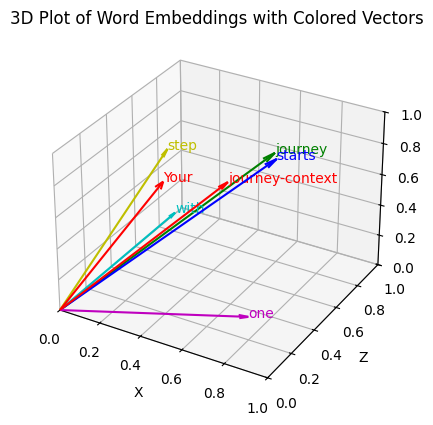

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], #Your
        [0.55, 0.87, 0.66], #Journey
        [0.57, 0.85, 0.64], #starts
        [0.22, 0.58, 0.33], #with
        [0.77, 0.25, 0.10], #one
        [0.05, 0.80, 0.55], #step
        [0.4419, 0.6515, 0.5683] #journey-context
    ]
)

# words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# extract x,y,z coords
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]
z_coords = inputs[:, 2]

#create 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

for x,y,z,word,color in zip(x_coords, y_coords, z_coords, words, colors):
    #create a vector from origin to the point (x,y,z) 
    ax.quiver(0,0,0,x,y,z, color=color, arrow_length_ratio=0.05)
    ax.text(x,y,z,word,fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel("X")  
ax.set_ylabel("Y")
ax.set_ylabel("Z")

#set plot limits to keep arrows within plot boundaries
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

Now we can extend this computation to calculate attention weights and context vectors for all inputs

First we compute the dot products of all pairs of inputs (query*input vector with each input as query)

In [35]:
attn_scores = torch.empty(6,6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Same output achieved with below code - for loops are slow

In [34]:
print(inputs @ inputs.T)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


now we normalize attn scores using softmax so that they sum to 1

In [36]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


Dim specifies along which dimension we want to sum to 1. So dim -1 means we want the last dimension to sum to 1, which is columns in this case. so all columns will sum to 1 i.e. if we sum a single row, it will sum to 1

Now we compute all context vectors using these attention weights

In [37]:
all_context_vec = attn_weights @ inputs

print(all_context_vec)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
